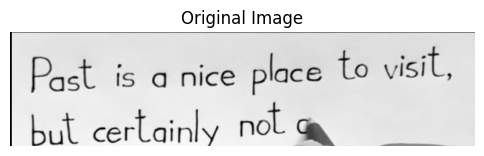

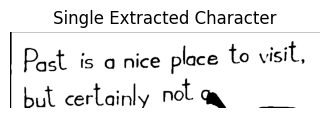

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("/Users/aaronbaggot/Desktop/Script2Text/data/samples/note.png", cv2.IMREAD_GRAYSCALE)

# Show ORIGINAL IMAGE
plt.figure(figsize=(6,4))
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

# Clean + threshold (keep white background)
blur = cv2.GaussianBlur(img, (5,5), 0)
_, bw = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Invert for connected components
inv = 255 - bw

# Connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(inv)

# Remove background (label 0)
components = stats[1:]

# Find biggest connected component (largest character)
largest_idx = np.argmax(components[:, cv2.CC_STAT_AREA])

# Bounding box
x, y, w, h, area = components[largest_idx]

# Crop single character
char = bw[y:y+h, x:x+w]

# Show SINGLE EXTRACTED CHARACTER
plt.figure(figsize=(4,4))
plt.imshow(char, cmap='gray')
plt.title("Single Extracted Character")
plt.axis("off")
plt.show()